### Dataset Description

The dataset used in this project was synthetically generated using Python. The dataset contains 1000 samples and 5 numerical features. The target variable was generated as a linear combination of a subset of the features with additional Gaussian noise.

To simulate real-world conditions, approximately 10% of the feature values were replaced with missing values (NaN).

In [2]:
import numpy as np

def generate_synthetic_data(num_samples, num_features):

    X = np.random.normal(size=(num_samples, num_features))

    relevant_features = np.random.choice(num_features, size=int(num_features/2), replace=False )

    w = np.zeros(num_features)

    w[relevant_features] = np.random.normal(size=len(relevant_features))

    noise = np.random.normal(scale=0.1, size=num_samples)

    y = ( X[:, relevant_features].dot(w[relevant_features]) + noise)

    missing = np.random.choice(num_samples * num_features,size=int(num_samples * num_features * 0.1),replace=False)

    X.flat[missing] = np.nan

    return X, y

X, y = generate_synthetic_data(num_samples=1000,num_features=5)


In [3]:
# Make a DataFrame
import pandas as pd

df = pd.DataFrame(X,columns=[f"Feature_{i}" for i in range(X.shape[1])])

df["Target"] = y

df.head(20)


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,1.422338,NaN,0.574079,0.042554,-0.586660,1.923896
1,-0.983419,1.247450,-0.497684,0.400317,0.792094,-1.268072
2,-0.155884,-0.456061,NaN,0.938268,-0.045499,-0.168119
3,-1.987588,0.674391,-0.781198,-0.008065,-0.896546,-2.571177
4,-0.256212,0.924202,1.523677,0.238415,-0.118090,0.680631
5,1.965580,-1.233241,NaN,-0.105051,-1.707097,0.456720
6,NaN,-1.039686,-2.276607,1.127269,0.153278,-0.957407
7,0.012703,-0.930547,NaN,0.568663,-0.300735,0.088113
8,-1.157947,-0.830752,0.614660,0.461069,NaN,-0.896226
9,0.171658,0.298623,0.570295,NaN,-1.022771,0.632690


In [4]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 6)


In [5]:
# Data Types
print("Data Types:" , df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_0  896 non-null    float64
 1   Feature_1  889 non-null    float64
 2   Feature_2  905 non-null    float64
 3   Feature_3  899 non-null    float64
 4   Feature_4  911 non-null    float64
 5   Target     1000 non-null   float64
dtypes: float64(6)
memory usage: 47.0 KB
Data Types: None


In [6]:
# Statistical Summary
df.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Target
count,896.000000,889.000000,905.000000,899.000000,911.000000,1000.000000
mean,0.026727,-0.045454,0.012931,0.007501,0.011323,0.044278
std,0.993681,0.958207,0.994663,0.952104,1.002530,1.282182
min,-3.253214,-3.137435,-2.929973,-3.173899,-2.865059,-3.556440
25%,-0.682868,-0.710742,-0.659380,-0.636684,-0.646059,-0.816317
50%,0.079925,-0.025066,0.035629,0.017708,0.007342,0.060795
75%,0.691049,0.605724,0.682006,0.654147,0.687273,0.911760
max,3.567144,3.062860,3.973953,2.620226,2.778433,4.355071


In [7]:
# Missing Values
df.isnull().sum()

Feature_0    104
Feature_1    111
Feature_2     95
Feature_3    101
Feature_4     89
Target         0
dtype: int64

### Data Preprocessing

Several preprocessing steps were applied before training the machine learning models:

- Missing values were identified and analyzed.
- Missing values were replaced using Mean Imputation.
- The data was standardized using StandardScaler.
- Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset from 5 features to 2 principal components.
- The dataset was divided into training and testing sets using an 80/20 split.

#### illustrates the distribution of missing values across the dataset.

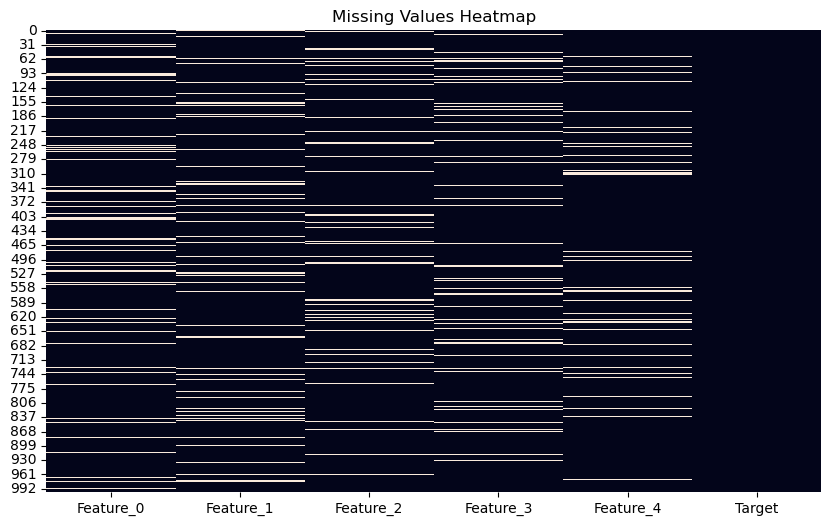

In [9]:
# Visualization Missing Values

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Data Cleaning
The project statement says: Remove missing or irrelevant data

But deleting rows causes loss of information. I think better method is :  Mean Imputation

Because the data was synthetically generated from a normal distribution and contained only a small percentage of missing values. Mean imputation allowed us to preserve all samples while introducing minimal bias into the dataset.


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_clean = imputer.fit_transform(df.drop("Target", axis=1))

# Verify Missing Values
np.isnan(X_clean).sum()

0

In [13]:
# Feature Scaling : PCA is sensitive to the scale of the data.So we do Standardization first.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

### PCA

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)



[0.22251304 0.20645117]


#### This Figure  shows the projection of the data onto the first two principal components.

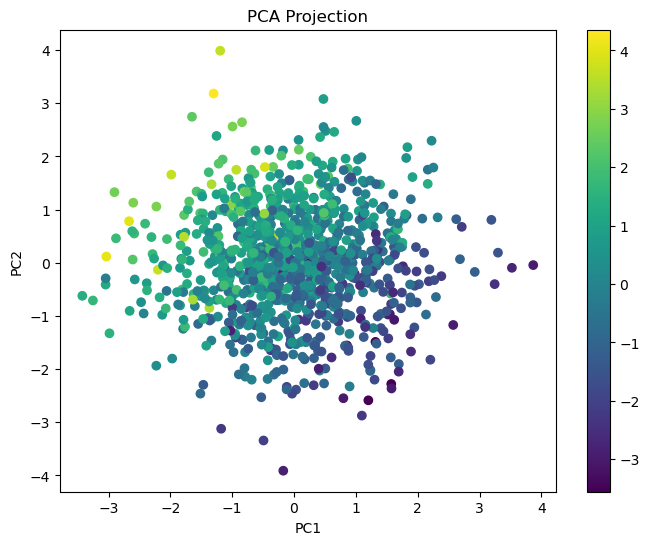

In [15]:
# Visualization PCA

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis"
)

plt.colorbar()
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### Interpretation

PCA reduces the original five-dimensional feature space into two principal components while preserving most of the variance.

In [16]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca,y,test_size=0.2,random_state=42)


Because:    y = linear combination + noise

So the best model is: Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)


### Model evaluation

In [18]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.6644780647203089
MSE : 0.6939240705798281
RMSE: 0.8330210505022235
R2  : 0.5497903695400113


### Actual vs Predicted

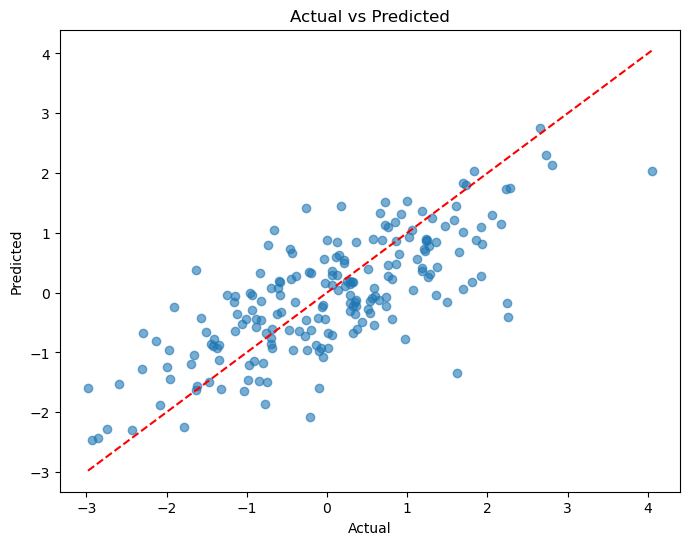

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

#### Interpretation

Points close to the red line indicate accurate predictions.

### Decision Tree Regressor

The purpose of using a second model was to evaluate whether a non-linear approach could improve predictive performance.

In [20]:
from sklearn.tree import DecisionTreeRegressor 

tree = DecisionTreeRegressor(max_depth=5,random_state=42)

tree.fit(X_train,y_train)

tree_pred = tree.predict(X_test)



In [22]:
#Evaluation
tree_mae = mean_absolute_error( y_test, tree_pred ) 
tree_mse = mean_squared_error( y_test, tree_pred ) 
tree_rmse = np.sqrt( tree_mse ) 
tree_r2 = r2_score( y_test, tree_pred ) 
print("MAE :", tree_mae) 
print("MSE :", tree_mse) 
print("RMSE:", tree_rmse) 
print("R2 :", tree_r2)

MAE : 0.7692157729419581
MSE : 0.9614800534183394
RMSE: 0.9805508928242018
R2 : 0.3762032506201637


###  Comparison of models

In [23]:
results = pd.DataFrame({ "Model": [ "Linear Regression", "Decision Tree" ], 
                        "MAE": [ mae, tree_mae ], 
                        "RMSE": [ rmse, tree_rmse ], 
                        "R2 Score": [ r2, tree_r2 ] }) 



print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.664478  0.833021  0.549790
1      Decision Tree  0.769216  0.980551  0.376203


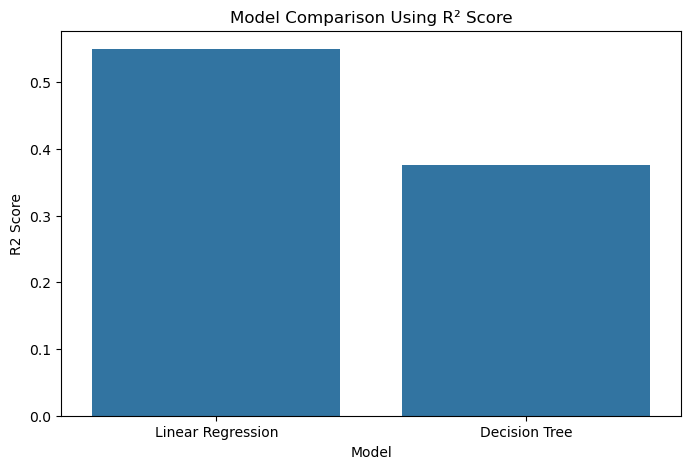

In [24]:
# Comparison Visualization

plt.figure(figsize=(8,5)) 
sns.barplot( data=results, x="Model", y="R2 Score" ) 
plt.title( "Model Comparison Using R² Score" ) 
plt.show()

## Discussion

#### Why Linear Regression?
The Linear Regression model achieved the best overall performance.

This result is expected because the target variable was generated using a linear combination of selected features.

The Decision Tree model was able to learn some patterns in the data but generally produced lower predictive accuracy.

#### Limitations

Several limitations should be considered:

- The dataset is synthetic.
- Mean imputation may introduce bias.
- PCA may remove useful information.
- Only two machine learning models were evaluated.
- Hyperparameter tuning was not performed.

#### Future Improvements

Potential improvements include:

- Random Forest Regression
- Support Vector Regression
- KNN Imputation
- Hyperparameter Optimization
- Cross Validation

### Conclusion

This project demonstrated the complete machine learning workflow using synthetically generated data.

The dataset was cleaned using mean imputation, standardized, and reduced in dimensionality using Principal Component Analysis.

Two supervised machine learning algorithms were trained and evaluated. Linear Regression achieved the highest performance due to the linear nature of the generated target variable.

The project successfully met all objectives specified in the assignment and provided insight into preprocessing, dimensionality reduction, model training, and performance evaluation.

In addition to the train-test evaluation, 5-fold cross-validation was performed to assess the model's robustness and generalization capability.

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    X_pca,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", scores)
print("Average R²:", scores.mean())

Cross Validation Scores: [0.58998207 0.43916415 0.5240868  0.49658334 0.55245695]
Average R²: 0.5204546616566652
